# Cuaderno Pre-Entrega Lab

En este cuaderno vamos a trabajar sobre las etapas necesarias para preparar la **Pre-Entrega del Proyecto Integrador** del curso de Machine Learning.

La idea principal de este taller no es entrenar todavía un modelo, sino dejar preparado un dataset para poder hacerlo más adelante. Para eso vamos a recorrer las etapas previas al modelado: selección del dataset, análisis inicial, limpieza, transformaciones básicas, selección de variables y división del conjunto de datos.

A lo largo del cuaderno vamos a trabajar con un dataset de ejemplo, pero muchas de las decisiones que tomemos podrán adaptarse a otros datasets. Por eso, además de resolver el caso propuesto, iremos explicando qué conviene observar y justificar en cada etapa.

El objetivo final es que cada estudiante pueda usar este recorrido como guía para construir su propia pre-entrega, con explicaciones claras, código funcional y decisiones justificadas.

## Objetivos del taller

Al finalizar este taller, deberías poder:

- elegir un dataset adecuado para una primera experiencia de Machine Learning;
- describir brevemente el problema que aborda ese dataset;
- realizar un diagnóstico inicial de los datos;
- detectar problemas básicos como valores faltantes, duplicados o columnas poco útiles;
- aplicar transformaciones necesarias para preparar los datos;
- seleccionar una variable objetivo y un conjunto de variables predictoras;
- dividir el dataset en datos de entrenamiento y datos de prueba.

Este cuaderno no busca llegar todavía al entrenamiento de un modelo. El propósito es dejar el dataset ordenado, limpio y preparado para continuar luego con la etapa de modelado.

## Hoja de ruta del cuaderno

Para preparar la pre-entrega vamos a seguir este recorrido:

1. Elegir y cargar un dataset.
2. Revisar rápidamente su estructura.
3. Identificar la variable objetivo.
4. Realizar un análisis exploratorio inicial.
5. Limpiar los datos.
6. Aplicar transformaciones básicas.
7. Seleccionar las variables que usaremos.
8. Separar los datos en entrenamiento y prueba.

La lógica general será:

**diagnosticar → limpiar → transformar → seleccionar → dividir**

Al finalizar, el dataset debería quedar listo para ser usado en la etapa de entrenamiento de modelos.

## ¿Cómo elegir un buen dataset?

Para esta pre-entrega conviene elegir un dataset **tabular**, es decir, organizado en filas y columnas, similar a una planilla de cálculo.

Algunos criterios útiles para elegirlo:

- que tenga una **variable objetivo clara**, es decir, aquello que más adelante se intentará predecir;
- que no sea demasiado grande ni demasiado complejo;
- que tenga varias columnas disponibles para analizar como posibles variables predictoras;
- que incluya datos numéricos y, si es posible, también datos categóricos;
- que el problema sea fácil de explicar en pocas líneas.

En esta etapa no buscamos resolver un problema complejo, sino practicar correctamente el proceso de preparación de datos para Machine Learning.

## Dataset elegido: especificaciones y precios de laptops

Para este taller vamos a trabajar con un dataset de laptops que contiene características técnicas de distintos equipos, junto con su precio.

Cada fila representa una laptop, y las columnas describen aspectos como marca, tipo de equipo, tamaño de pantalla, resolución, procesador, placa gráfica, sistema operativo, memoria RAM, peso, almacenamiento y precio.

La variable que más adelante se podría intentar predecir es `Price`, que representa el precio de la laptop. Por lo tanto, este dataset permite preparar un problema de **regresión**, ya que el objetivo sería estimar un valor numérico.

Elegimos este dataset porque:

- es tabular;
- tiene un tamaño manejable;
- tiene una variable objetivo clara;
- está relacionado con características de hardware fáciles de interpretar;
- permite realizar limpieza, transformaciones y selección de variables;
- deja preparado el camino para entrenar modelos de Machine Learning en la entrega final.

En este cuaderno todavía no vamos a entrenar modelos. El objetivo será preparar correctamente los datos para que esa etapa pueda realizarse más adelante.

## Preparación del entorno de trabajo

Antes de cargar y analizar el dataset, necesitamos importar algunas librerías de Python.

Usaremos `pandas` y `numpy` para trabajar con los datos, `matplotlib` y `seaborn` para realizar algunas visualizaciones básicas, y `kagglehub` para descargar el dataset directamente desde Kaggle.

También importaremos `os`, que nos permitirá recorrer carpetas y ubicar el archivo CSV descargado.

In [ ]:
# Instalamos (si es necesario) kagglehub para poder descargar
# datasets desde Kaggle. Normalmente, Colab lo tiene incorporado.
# !pip install kagglehub -q

# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para descargar y ubicar archivos
import kagglehub
import os

## Descarga del dataset

El dataset se descargará directamente desde Kaggle usando `kagglehub`.

Esto permite que el cuaderno sea más fácil de ejecutar en Colab, ya que no necesitamos subir manualmente el archivo CSV. Al ejecutar la celda siguiente, Kaggle descargará el dataset y nos devolverá la ruta donde quedó guardado.

In [ ]:
# Descargamos el dataset desde Kaggle
ruta_dataset = kagglehub.dataset_download("nabihazahid/laptop-details-dataset")

# Mostramos la ruta donde quedó descargado
print("Dataset descargado en:")
print(ruta_dataset)

Using Colab cache for faster access to the 'laptop-details-dataset' dataset.
Dataset descargado en:
/kaggle/input/laptop-details-dataset


## Revisión de archivos descargados

Antes de cargar el dataset, vamos a revisar qué archivos contiene la carpeta descargada.

Este paso es útil porque muchos datasets pueden incluir varios archivos. En este caso, necesitamos identificar cuál es el archivo CSV principal que vamos a usar en el cuaderno.

In [ ]:
# Recorremos la carpeta descargada y mostramos los archivos disponibles
for carpeta, subcarpetas, archivos in os.walk(ruta_dataset):
    for archivo in archivos:
        print(os.path.join(carpeta, archivo))

/kaggle/input/laptop-details-dataset/laptop_scrap_data.csv


## Carga del dataset en un DataFrame

El archivo principal del dataset se llama `laptop_scrap_data.csv`.

Vamos a cargarlo en un DataFrame de pandas llamado `df`. A partir de este momento, `df` será la tabla principal con la que trabajaremos durante el cuaderno.

Luego mostraremos las primeras filas para tener una primera idea de cómo están organizados los datos.

In [ ]:
# Definimos la ruta del archivo CSV
ruta_csv = os.path.join(ruta_dataset, "laptop_scrap_data.csv")

# Cargamos el archivo en un DataFrame
df = pd.read_csv(ruta_csv)

# Mostramos las primeras filas del dataset
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Gpu,OpSys,TouchScreen,Ips,X_res,...,ppi,Dedicated_Gpu,Ram_GB,Weight_kg,SSD,HHD,Storage_Type,Total_Storage_GB,Storage_Category,Price
0,MSI,MSI Prestige 16 AI+,16.0,2880 x 1800,Intel Core Ultra X7 358H,Intel Arc B390,Windows,0.0,0.0,2880.0,...,212.26,1.0,64.0,1.59,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2728.8
1,MSI,MSI Prestige 16 AI+,16.0,2880 x 1800,Intel Core Ultra 9 386H,Intel Graphics (4-Cores),Windows,0.0,0.0,2880.0,...,212.26,0.0,64.0,1.59,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2528.8
2,ASUS,ASUS Vivobook S16,16.0,1920 x 1200,AMD Ryzen AI 5 330,AMD Radeon 820M,Windows,0.0,0.0,1920.0,...,141.51,1.0,24.0,1.70,4000.0,0.0,SSD Only,4000.0,Very High (> 2TB),2428.8
3,Toshiba,Dynabook X series,13.3,1920 x 1200,Intel Core i5-1350P,Intel Iris Xe Graphics G7 (80EU),Windows,1.0,1.0,1920.0,...,170.24,0.0,16.0,0.93,512.0,0.0,SSD Only,512.0,Standard (512GB-1TB),1390.2
4,Lenovo,"Lenovo Legion 5a (15"", Gen 11, 15AGP11)",15.3,2560 x 1600,AMD Ryzen AI 9 465,NVIDIA GeForce RTX 5060 (Laptop),Windows,0.0,0.0,2560.0,...,197.31,1.0,32.0,1.87,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2067.8


## Diagnóstico inicial del dataset

Antes de limpiar o transformar los datos, necesitamos conocer la estructura general del dataset.

En esta etapa vamos a revisar:

- cuántas filas y columnas tiene;
- qué columnas están disponibles;
- qué tipo de dato tiene cada columna;
- si existen valores faltantes.

Este diagnóstico inicial nos ayudará a tomar decisiones en las próximas etapas del cuaderno.

In [ ]:
# Mostramos las dimensiones del dataset
print("Dimensiones del dataset:")
print(df.shape)

# Mostramos los nombres de las columnas
print("\nColumnas disponibles:")
print(df.columns.tolist())

# Mostramos los tipos de datos de cada columna
print("\nTipos de datos:")
print(df.dtypes)

# Revisamos la cantidad de valores faltantes por columna
print("\nValores faltantes por columna:")
print(df.isnull().sum())

Dimensiones del dataset:
(1563, 21)

Columnas disponibles:
['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Gpu', 'OpSys', 'TouchScreen', 'Ips', 'X_res', 'Y_res', 'ppi', 'Dedicated_Gpu', 'Ram_GB', 'Weight_kg', 'SSD', 'HHD', 'Storage_Type', 'Total_Storage_GB', 'Storage_Category', 'Price']

Tipos de datos:
Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Gpu                  object
OpSys                object
TouchScreen         float64
Ips                 float64
X_res               float64
Y_res               float64
ppi                 float64
Dedicated_Gpu       float64
Ram_GB              float64
Weight_kg           float64
SSD                 float64
HHD                 float64
Storage_Type         object
Total_Storage_GB    float64
Storage_Category     object
Price               float64
dtype: object

Valores faltantes por columna:
Company             3
TypeName            3
Inc

## Revisión de valores faltantes

El diagnóstico inicial muestra que todas las columnas tienen 3 valores faltantes.

Cuando ocurre esto, es posible que los valores faltantes estén concentrados en algunas filas completas, en lugar de estar distribuidos por todo el dataset.

Por eso, antes de decidir qué hacer, vamos a mostrar las filas que contienen al menos un valor faltante.

In [ ]:
# Mostramos las filas que tienen al menos un valor faltante
filas_con_nulos = df[df.isnull().any(axis=1)]

filas_con_nulos

,Company,TypeName,Inches,ScreenResolution,Cpu,Gpu,OpSys,TouchScreen,Ips,X_res,...,ppi,Dedicated_Gpu,Ram_GB,Weight_kg,SSD,HHD,Storage_Type,Total_Storage_GB,Storage_Category,Price
1560,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1561,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Limpieza de filas vacías

Las filas con valores faltantes están completamente vacías. No contienen información sobre ninguna laptop ni tampoco tienen valor en la variable objetivo `Price`.

Por ese motivo, vamos a eliminarlas del dataset.

Esta decisión es razonable porque no estamos descartando registros parcialmente útiles, sino filas que no aportan datos para el análisis ni para el futuro modelo.

In [ ]:
# Eliminamos las filas completamente vacías
df = df.dropna(how="all")

# Mostramos las nuevas dimensiones del dataset
print("Dimensiones luego de eliminar filas vacías:")
print(df.shape)

# Verificamos nuevamente si quedan valores faltantes
print("\nValores faltantes por columna:")
print(df.isnull().sum())

Dimensiones luego de eliminar filas vacías:
(1560, 21)

Valores faltantes por columna:
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Gpu                 0
OpSys               0
TouchScreen         0
Ips                 0
X_res               0
Y_res               0
ppi                 0
Dedicated_Gpu       0
Ram_GB              0
Weight_kg           0
SSD                 0
HHD                 0
Storage_Type        0
Total_Storage_GB    0
Storage_Category    0
Price               0
dtype: int64


## Revisión de filas duplicadas

Además de los valores faltantes, también conviene revisar si el dataset contiene filas duplicadas.

Una fila duplicada sería un registro repetido exactamente igual a otro. Si existieran muchos duplicados, podrían afectar el análisis y también el entrenamiento de un modelo, porque ciertos casos quedarían representados más veces de lo necesario.

En esta celda vamos a contar cuántas filas duplicadas hay en el dataset.

In [ ]:
# Contamos la cantidad de filas duplicadas
cantidad_duplicados = df.duplicated().sum()

print("Cantidad de filas duplicadas:")
print(cantidad_duplicados)

Cantidad de filas duplicadas:
0


## Resultado de la revisión de duplicados

El dataset no contiene filas duplicadas.

Por lo tanto, no es necesario eliminar registros en esta etapa. Continuaremos trabajando con las 1560 filas disponibles.

## Resumen estadístico de variables numéricas

Ahora vamos a revisar un resumen estadístico de las variables numéricas.

Este resumen permite observar valores mínimos, máximos, promedios y medidas de dispersión. Nos ayuda a detectar posibles valores extraños, por ejemplo precios demasiado bajos o altos, cantidades de memoria poco frecuentes, o pesos que no tengan sentido para una laptop.

In [ ]:
# Mostramos un resumen estadístico de las columnas numéricas
df.describe()

,Inches,TouchScreen,Ips,X_res,Y_res,ppi,Dedicated_Gpu,Ram_GB,Weight_kg,SSD,HHD,Total_Storage_GB,Price
count,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000
mean,15.311859,0.726282,0.715385,2059.143590,1235.560256,157.689654,0.604487,29.324359,1.789615,1411.446154,5.025641,1416.471795,1947.008051
std,1.128081,0.446009,0.451376,431.366919,301.650510,36.177101,0.489117,22.203963,0.488822,1374.868914,24.185182,1369.910037,693.184352
min,7.000000,0.000000,0.000000,1280.000000,720.000000,84.890000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,305.990000
25%,14.000000,0.000000,0.000000,1920.000000,1080.000000,141.210000,0.000000,16.000000,1.460000,512.000000,0.000000,512.000000,1496.800000
50%,15.600000,1.000000,1.000000,1920.000000,1200.000000,141.510000,1.000000,24.000000,1.700000,1000.000000,0.000000,1000.000000,1807.800000
75%,16.000000,1.000000,1.000000,1920.000000,1200.000000,161.730000,1.000000,32.000000,2.050000,2000.000000,0.000000,2000.000000,2227.800000
max,18.000000,1.000000,1.000000,3840.000000,2400.000000,323.450000,1.000000,192.000000,4.120000,12000.000000,128.000000,12000.000000,7488.800000


## Revisión de valores problemáticos en el peso

En el resumen estadístico observamos que la columna `Weight_kg` tiene un valor mínimo de 0.

Aunque el valor 0 es numéricamente válido, no tiene sentido en este contexto: una laptop no puede pesar 0 kg. Por eso, vamos a considerar esos casos como datos problemáticos.

Antes de corregirlos, vamos a contar cuántos registros tienen `Weight_kg = 0`.

In [ ]:
# Contamos cuántos registros tienen peso igual a 0
cantidad_peso_cero = (df["Weight_kg"] == 0).sum()

print("Cantidad de registros con Weight_kg = 0:")
print(cantidad_peso_cero)

print("\nPorcentaje sobre el total:")
print(cantidad_peso_cero / len(df) * 100)

Cantidad de registros con Weight_kg = 0:
11

Porcentaje sobre el total:
0.7051282051282052


## Corrección de pesos iguales a cero

Encontramos 11 registros con `Weight_kg = 0`, lo que representa menos del 1% del dataset.

Como esos registros tienen información útil en las demás columnas, no vamos a eliminarlos. En su lugar, vamos a interpretar el peso 0 como un dato faltante mal registrado.

La estrategia será:

1. reemplazar los valores 0 por `NaN`;
2. calcular la mediana de la columna `Weight_kg`;
3. completar los valores faltantes con esa mediana.

Usamos la mediana porque es una medida más resistente a valores extremos que el promedio.

In [ ]:
# Reemplazamos los pesos iguales a 0 por NaN
df["Weight_kg"] = df["Weight_kg"].replace(0, np.nan)

# Calculamos la mediana del peso
mediana_peso = df["Weight_kg"].median()

# Completamos los valores faltantes con la mediana
df["Weight_kg"] = df["Weight_kg"].fillna(mediana_peso)

# Verificamos el resultado
print("Mediana utilizada para completar los pesos faltantes:")
print(mediana_peso)

print("\nCantidad de registros con Weight_kg = 0 luego de la corrección:")
print((df["Weight_kg"] == 0).sum())

print("\nPeso mínimo luego de la corrección:")
print(df["Weight_kg"].min())

Mediana utilizada para completar los pesos faltantes:
1.7

Cantidad de registros con Weight_kg = 0 luego de la corrección:
0

Peso mínimo luego de la corrección:
0.6


## Estado del dataset luego de la limpieza inicial

Hasta este punto realizamos las siguientes acciones:

- eliminamos 3 filas completamente vacías;
- verificamos que no hubiera filas duplicadas;
- detectamos valores problemáticos en `Weight_kg`;
- reemplazamos los pesos iguales a 0 por la mediana de la columna.

Luego de estas correcciones, el dataset queda sin valores faltantes y con valores más coherentes para continuar el análisis.

## Distribución de la variable objetivo

La variable objetivo de este trabajo es `Price`, es decir, el precio de cada laptop.

Antes de preparar los datos para un modelo, conviene observar cómo se distribuyen esos precios. Esto nos permite detectar si la mayoría de los equipos se concentra en ciertos rangos, si hay valores muy altos o bajos, y si la variable presenta una distribución equilibrada o sesgada.

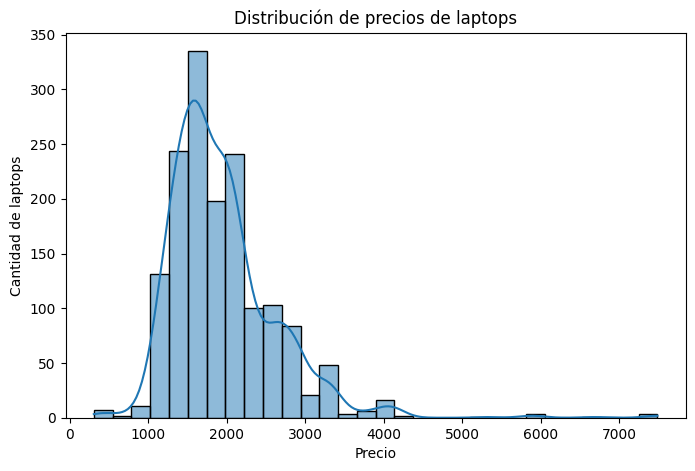

In [ ]:
# Graficamos la distribución de la variable objetivo Price
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Price", bins=30, kde=True)

plt.title("Distribución de precios de laptops")
plt.xlabel("Precio")
plt.ylabel("Cantidad de laptops")

plt.show()

### Interpretación de la distribución de precios

La mayoría de las laptops del dataset se concentra en un rango de precios intermedio, aproximadamente entre 1000 y 3000.

También se observan algunos valores bastante más altos, que podrían corresponder a equipos premium, workstations o laptops orientadas a gaming. Por ahora no los eliminaremos automáticamente, ya que pueden ser casos reales y útiles para que el futuro modelo aprenda diferencias entre equipos de distintas gamas.

Esta observación será importante más adelante, cuando se evalúe el rendimiento de un modelo de regresión.

## Relación entre memoria RAM y precio

Una de las variables técnicas que puede influir en el precio de una laptop es la memoria RAM.

A continuación vamos a observar la relación entre `Ram_GB` y `Price`. Esta visualización no demuestra causalidad, pero puede ayudarnos a detectar si existe una tendencia general entre ambas variables.

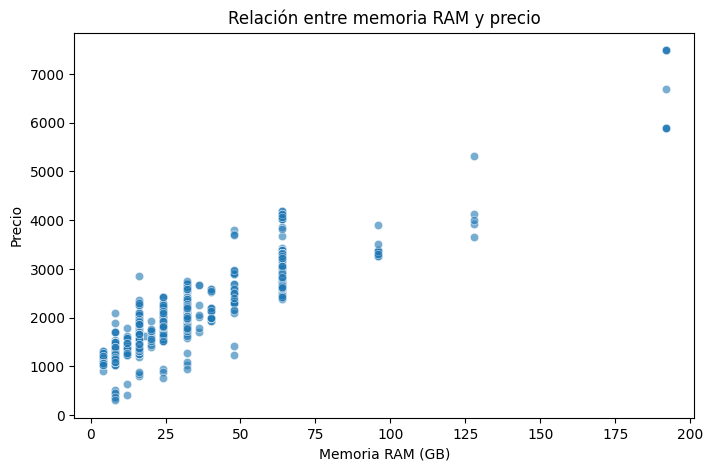

In [ ]:
# Graficamos la relación entre memoria RAM y precio
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Ram_GB", y="Price", alpha=0.6)

plt.title("Relación entre memoria RAM y precio")
plt.xlabel("Memoria RAM (GB)")
plt.ylabel("Precio")

plt.show()

### Interpretación de la relación entre RAM y precio

El gráfico muestra una tendencia positiva: a medida que aumenta la memoria RAM, también tiende a aumentar el precio de la laptop.

Esto no significa que la RAM sea la única variable que explica el precio, pero sí sugiere que puede ser una característica relevante para un futuro modelo.

También se observan algunos equipos con cantidades muy altas de RAM, como 128 GB o 192 GB. Por ahora no los eliminaremos, ya que pueden representar equipos de gama alta o estaciones de trabajo.

## Relación entre almacenamiento total y precio

Otra característica técnica importante es la capacidad de almacenamiento.

En esta celda vamos a analizar la relación entre `Total_Storage_GB` y `Price`. Esto nos permitirá observar si los equipos con mayor capacidad de almacenamiento tienden a ubicarse en rangos de precio más altos.

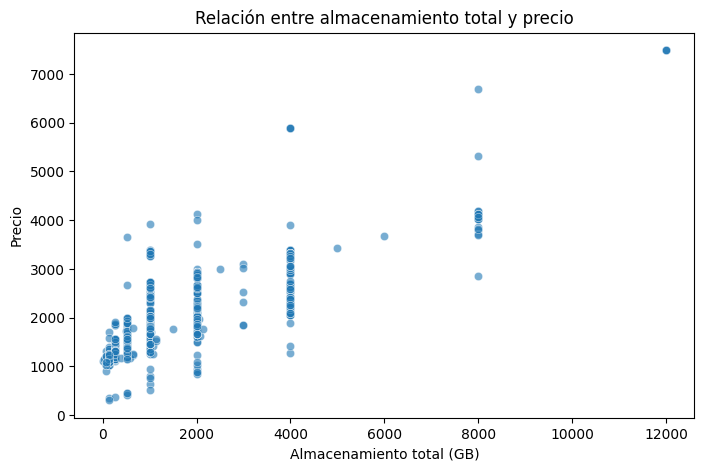

In [ ]:
# Graficamos la relación entre almacenamiento total y precio
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Total_Storage_GB", y="Price", alpha=0.6)

plt.title("Relación entre almacenamiento total y precio")
plt.xlabel("Almacenamiento total (GB)")
plt.ylabel("Precio")

plt.show()

### Interpretación de la relación entre almacenamiento y precio

El gráfico muestra que, en general, las laptops con mayor capacidad de almacenamiento tienden a tener precios más altos.

Sin embargo, la relación no es perfecta. Hay equipos con capacidades similares de almacenamiento pero precios diferentes. Esto indica que el precio depende de varias características combinadas, no de una única variable.

También se observan algunos valores altos de almacenamiento, como 8000 GB o 12000 GB. Por ahora los conservaremos, porque pueden corresponder a configuraciones de gama alta.

## Matriz de correlación

Para completar el análisis exploratorio inicial, vamos a calcular una matriz de correlación entre las variables numéricas.

La correlación permite observar qué tan relacionadas están dos variables numéricas. Los valores cercanos a 1 indican una relación positiva fuerte, los valores cercanos a -1 indican una relación negativa fuerte, y los valores cercanos a 0 indican poca relación lineal.

En este caso nos interesa especialmente observar qué variables parecen estar más relacionadas con `Price`.

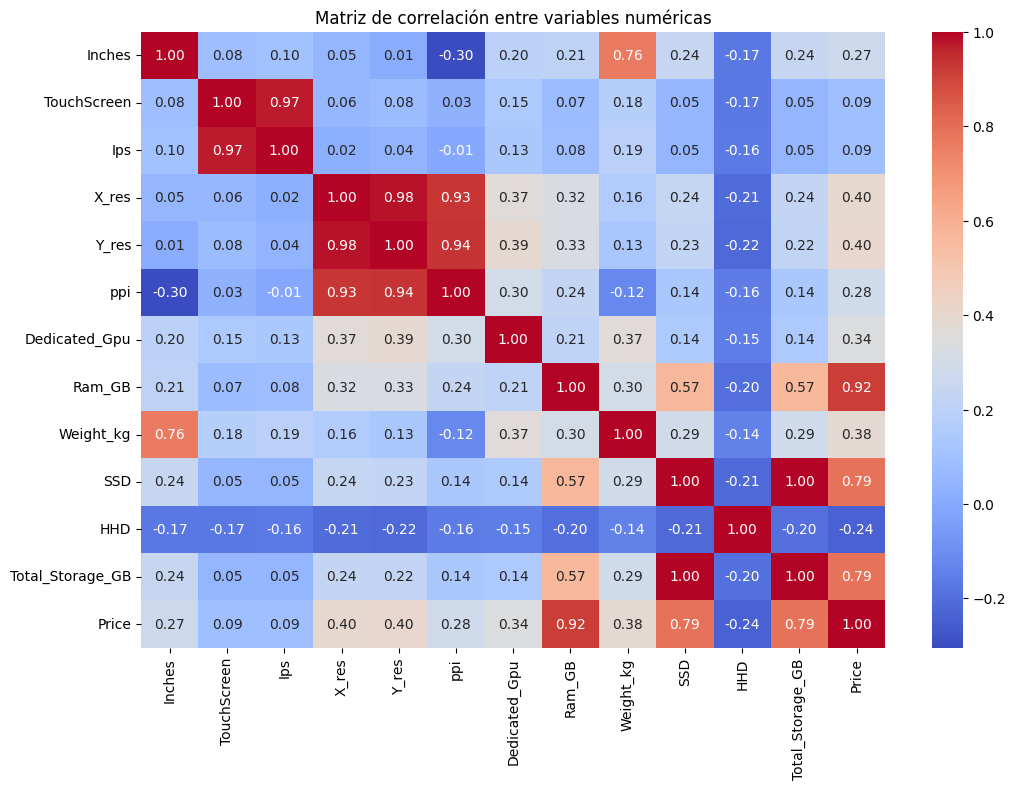

In [ ]:
# Calculamos la matriz de correlación entre variables numéricas
matriz_correlacion = df.corr(numeric_only=True)

# Graficamos la matriz de correlación
plt.figure(figsize=(12, 8))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación entre variables numéricas")

plt.show()

### Interpretación de la matriz de correlación

La matriz de correlación muestra que algunas variables numéricas tienen una relación más fuerte con `Price`.

En particular, se observa una correlación alta entre `Ram_GB` y `Price`, y también una relación importante entre `SSD`, `Total_Storage_GB` y `Price`.

Otras variables, como la resolución de pantalla (`X_res` e `Y_res`), el peso (`Weight_kg`) y la presencia de GPU dedicada (`Dedicated_Gpu`), muestran relaciones moderadas con el precio.

Esta información no alcanza por sí sola para definir el modelo final, pero ayuda a identificar variables que podrían ser relevantes en una etapa posterior.

## Transformaciones básicas

Antes de entrenar un modelo de Machine Learning, los datos deben estar en un formato adecuado.

En general, los modelos no trabajan directamente con texto. Por eso, las variables categóricas deben transformarse en valores numéricos. Además, algunas variables numéricas pueden necesitar escalado, especialmente si más adelante se usan modelos sensibles a la escala, como KNN o regresión logística.

En esta etapa vamos a identificar qué columnas son numéricas y cuáles son categóricas.

In [ ]:
# Identificamos columnas numéricas
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Identificamos columnas categóricas
columnas_categoricas = df.select_dtypes(include=["object"]).columns.tolist()

print("Columnas numéricas:")
print(columnas_numericas)

print("\nColumnas categóricas:")
print(columnas_categoricas)

Columnas numéricas:
['Inches', 'TouchScreen', 'Ips', 'X_res', 'Y_res', 'ppi', 'Dedicated_Gpu', 'Ram_GB', 'Weight_kg', 'SSD', 'HHD', 'Total_Storage_GB', 'Price']

Columnas categóricas:
['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Gpu', 'OpSys', 'Storage_Type', 'Storage_Category']


## Separación de variable objetivo y variables predictoras

En este dataset, la variable objetivo es `Price`, porque representa el valor que más adelante se intentará predecir.

El resto de las columnas pueden funcionar como variables predictoras, es decir, como características que podrían ayudar al modelo a estimar el precio.

Antes de aplicar transformaciones, vamos a separar:

- `X`: variables predictoras;
- `y`: variable objetivo.

In [ ]:
# Separamos la variable objetivo
y = df["Price"]

# Separamos las variables predictoras
X = df.drop(columns=["Price"])

# Verificamos las dimensiones
print("Dimensiones de X:")
print(X.shape)

print("\nDimensiones de y:")
print(y.shape)

Dimensiones de X:
(1560, 20)

Dimensiones de y:
(1560,)


## Identificación de columnas predictoras numéricas y categóricas

Ahora que separamos `Price`, vamos a volver a identificar las columnas numéricas y categóricas dentro de `X`.

Esto es importante porque las transformaciones se aplican de manera diferente según el tipo de variable:

- las variables numéricas pueden escalarse;
- las variables categóricas deben codificarse para convertirse en valores numéricos.

In [ ]:
# Identificamos columnas numéricas dentro de X
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Identificamos columnas categóricas dentro de X
columnas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Columnas numéricas predictoras:")
print(columnas_numericas)

print("\nColumnas categóricas predictoras:")
print(columnas_categoricas)

Columnas numéricas predictoras:
['Inches', 'TouchScreen', 'Ips', 'X_res', 'Y_res', 'ppi', 'Dedicated_Gpu', 'Ram_GB', 'Weight_kg', 'SSD', 'HHD', 'Total_Storage_GB']

Columnas categóricas predictoras:
['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Gpu', 'OpSys', 'Storage_Type', 'Storage_Category']


## Revisión de variables categóricas

Las variables categóricas contienen texto o etiquetas, por ejemplo la marca de la laptop, el sistema operativo o el tipo de almacenamiento.

Antes de codificarlas, conviene revisar cuántos valores distintos tiene cada una. Si una columna tiene demasiadas categorías diferentes, puede volver más complejo el dataset después de la codificación.

En esta celda vamos a contar la cantidad de valores únicos de cada variable categórica.

In [ ]:
# Contamos la cantidad de valores únicos en cada columna categórica
for columna in columnas_categoricas:
    print(f"{columna}: {X[columna].nunique()} valores únicos")

Company: 18 valores únicos
TypeName: 455 valores únicos
ScreenResolution: 29 valores únicos
Cpu: 230 valores únicos
Gpu: 134 valores únicos
OpSys: 3 valores únicos
Storage_Type: 3 valores únicos
Storage_Category: 6 valores únicos


### Observación sobre las variables categóricas

Al revisar las variables categóricas, vemos que no todas tienen el mismo nivel de complejidad.

Algunas columnas tienen pocos valores únicos, como `OpSys`, `Storage_Type` y `Storage_Category`. Estas variables son fáciles de transformar mediante codificación.

Otras columnas, como `TypeName`, `Cpu` y `Gpu`, tienen muchos valores distintos. Esto puede hacer que, al codificarlas, el dataset final tenga muchas columnas nuevas.

Por este motivo, antes de aplicar transformaciones definitivas, vamos a seleccionar un conjunto de variables relevantes y manejables para continuar con la preparación del dataset.

## Selección de variables relevantes

Para preparar el dataset para un futuro modelo, no siempre conviene usar todas las columnas disponibles.

En este caso vamos a seleccionar variables que cumplan con dos condiciones:

- que tengan relación con las características técnicas de la laptop;
- que sean relativamente simples de transformar y utilizar.

Algunas columnas, como `TypeName`, `Cpu` y `Gpu`, contienen información muy detallada y muchos valores distintos. Más adelante podrían analizarse con técnicas específicas, pero para esta pre-entrega vamos a trabajar con un conjunto de variables más general y manejable.

In [ ]:
# Seleccionamos un conjunto de variables predictoras relevantes y manejables
columnas_seleccionadas = [
    "Company",
    "Inches",
    "TouchScreen",
    "Ips",
    "X_res",
    "Y_res",
    "ppi",
    "Dedicated_Gpu",
    "Ram_GB",
    "Weight_kg",
    "SSD",
    "HHD",
    "Total_Storage_GB",
    "OpSys",
    "Storage_Type",
    "Storage_Category"
]

# Creamos una nueva versión de X con las columnas seleccionadas
X = X[columnas_seleccionadas]

# Mostramos las primeras filas del nuevo conjunto de variables predictoras
X.head()

,Company,Inches,TouchScreen,Ips,X_res,Y_res,ppi,Dedicated_Gpu,Ram_GB,Weight_kg,SSD,HHD,Total_Storage_GB,OpSys,Storage_Type,Storage_Category
0,MSI,16.0,0.0,0.0,2880.0,1800.0,212.26,1.0,64.0,1.59,1000.0,0.0,1000.0,Windows,SSD Only,Standard (512GB-1TB)
1,MSI,16.0,0.0,0.0,2880.0,1800.0,212.26,0.0,64.0,1.59,1000.0,0.0,1000.0,Windows,SSD Only,Standard (512GB-1TB)
2,ASUS,16.0,0.0,0.0,1920.0,1200.0,141.51,1.0,24.0,1.70,4000.0,0.0,4000.0,Windows,SSD Only,Very High (> 2TB)
3,Toshiba,13.3,1.0,1.0,1920.0,1200.0,170.24,0.0,16.0,0.93,512.0,0.0,512.0,Windows,SSD Only,Standard (512GB-1TB)
4,Lenovo,15.3,0.0,0.0,2560.0,1600.0,197.31,1.0,32.0,1.87,1000.0,0.0,1000.0,Windows,SSD Only,Standard (512GB-1TB)


## Revisión de columnas luego de la selección

Después de seleccionar las variables que vamos a utilizar, volvemos a identificar cuáles son numéricas y cuáles son categóricas.

Esto es necesario porque las transformaciones se aplicarán de manera diferente según el tipo de dato:

- las columnas numéricas serán escaladas;
- las columnas categóricas serán codificadas.

In [ ]:
# Volvemos a identificar columnas numéricas y categóricas luego de la selección
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Columnas numéricas seleccionadas:")
print(columnas_numericas)

print("\nColumnas categóricas seleccionadas:")
print(columnas_categoricas)

Columnas numéricas seleccionadas:
['Inches', 'TouchScreen', 'Ips', 'X_res', 'Y_res', 'ppi', 'Dedicated_Gpu', 'Ram_GB', 'Weight_kg', 'SSD', 'HHD', 'Total_Storage_GB']

Columnas categóricas seleccionadas:
['Company', 'OpSys', 'Storage_Type', 'Storage_Category']


## Definición de transformaciones básicas

Para que los datos puedan ser utilizados por un modelo de Machine Learning, necesitamos transformar las variables predictoras.

En este caso aplicaremos dos transformaciones:

- a las variables numéricas les aplicaremos escalado con `StandardScaler`;
- a las variables categóricas les aplicaremos codificación con `OneHotEncoder`.

El escalado permite que las variables numéricas queden en una escala comparable. La codificación convierte categorías de texto, como la marca o el sistema operativo, en columnas numéricas que un modelo puede interpretar.

Por buena práctica, definiremos estas transformaciones ahora, pero las aplicaremos después de dividir el dataset en entrenamiento y prueba.

In [ ]:
# Importamos las herramientas para transformar los datos
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Definimos el preprocesamiento para columnas numéricas y categóricas
preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
    ]
)

#preprocesamiento

## División en entrenamiento y prueba

Antes de entrenar un modelo, es necesario separar el dataset en dos partes:

- un conjunto de **entrenamiento**, que se usará para que el modelo aprenda;
- un conjunto de **prueba**, que se usará más adelante para evaluar qué tan bien funciona el modelo con datos que no vio durante el entrenamiento.

Aunque en esta pre-entrega todavía no vamos a entrenar modelos, sí debemos dejar preparada esta separación.

Usaremos un 80% de los datos para entrenamiento y un 20% para prueba.

In [ ]:
# Importamos la función para dividir el dataset
from sklearn.model_selection import train_test_split

# Dividimos las variables predictoras y la variable objetivo
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Mostramos las dimensiones resultantes
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (1248, 16)
Dimensiones de X_test: (312, 16)
Dimensiones de y_train: (1248,)
Dimensiones de y_test: (312,)


## Aplicación del preprocesamiento

Ahora vamos a aplicar las transformaciones definidas anteriormente.

Usaremos:

- `fit_transform()` sobre `X_train`, para que el preprocesamiento aprenda los parámetros necesarios a partir de los datos de entrenamiento;
- `transform()` sobre `X_test`, para aplicar esas mismas transformaciones al conjunto de prueba.

Esto evita que la información del conjunto de prueba influya en la preparación de los datos.

In [ ]:
# Aplicamos el preprocesamiento al conjunto de entrenamiento
X_train_preparado = preprocesamiento.fit_transform(X_train)

# Aplicamos el mismo preprocesamiento al conjunto de prueba
X_test_preparado = preprocesamiento.transform(X_test)

# Mostramos las dimensiones luego del preprocesamiento
print("Dimensiones de X_train_preparado:", X_train_preparado.shape)
print("Dimensiones de X_test_preparado:", X_test_preparado.shape)

Dimensiones de X_train_preparado: (1248, 42)
Dimensiones de X_test_preparado: (312, 42)


## Resultado del preprocesamiento

Luego de aplicar el preprocesamiento, los conjuntos de datos quedaron con 42 columnas.

Esto ocurre porque las variables categóricas fueron codificadas mediante `OneHotEncoder`. Esta técnica crea nuevas columnas numéricas a partir de las categorías originales.

Por ejemplo, una columna como `Company`, que contiene distintas marcas de laptops, se transforma en varias columnas binarias, una por cada marca.

De esta manera, el dataset queda en un formato adecuado para ser utilizado por modelos de Machine Learning.

## Checklist final de la Pre-Entrega

En este cuaderno recorrimos las etapas principales solicitadas para la Pre-Entrega del Proyecto Integrador:

- seleccionamos un dataset tabular con una variable objetivo clara;
- describimos brevemente el problema que podría abordarse con esos datos;
- realizamos un análisis exploratorio inicial;
- revisamos valores faltantes, duplicados y valores problemáticos;
- aplicamos decisiones de limpieza justificadas;
- identificamos variables numéricas y categóricas;
- seleccionamos un conjunto de variables relevantes y manejables;
- definimos transformaciones básicas para preparar los datos;
- dividimos el dataset en conjuntos de entrenamiento y prueba;
- aplicamos el preprocesamiento sin utilizar información del conjunto de prueba.

A partir de este punto, el dataset queda preparado para la siguiente etapa del proyecto: el entrenamiento y evaluación de modelos de Machine Learning.

En la entrega final, se podrá utilizar esta base preparada para probar distintos modelos de regresión que intenten estimar el precio de una laptop a partir de sus características técnicas.

## Cierre

La Pre-Entrega no busca obtener todavía un modelo final, sino demostrar que el dataset fue comprendido, revisado y preparado correctamente.

Un buen trabajo en esta etapa facilita mucho la entrega final, porque permite llegar al modelado con datos más ordenados, variables seleccionadas y una división clara entre entrenamiento y prueba.

El próximo paso será entrenar modelos, comparar sus resultados y analizar cuál funciona mejor para el problema planteado.